Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Load MNIST Dataset

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

print("Training data shape :", X_train_full.shape)
print("Training labels shape :", y_train_full.shape)

print("Test data shape :", X_test.shape)
print("Test labels shape :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape : (60000, 28, 28)
Training labels shape : (60000,)
Test data shape : (10000, 28, 28)
Test labels shape : (10000,)


Display MNIST images

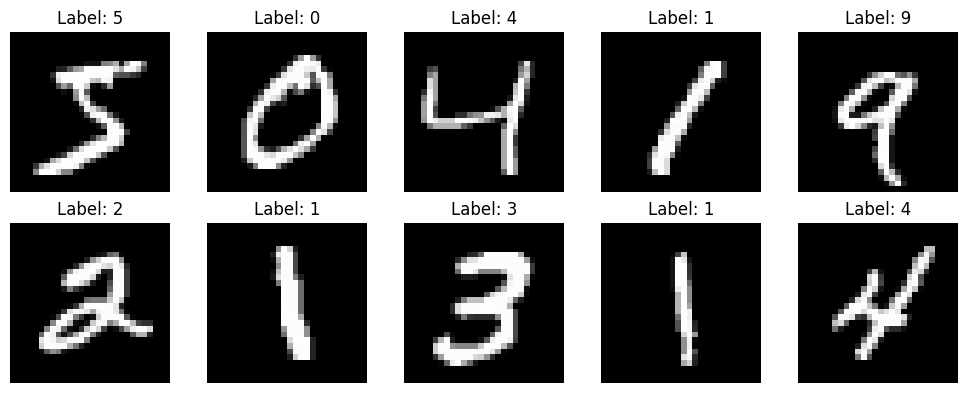

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(f"Label: {y_train_full[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Preprocessing and Validation Split

In [ ]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)
print("Training set :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set :", X_test.shape)

Training set : (48000, 28, 28)
Validation set : (12000, 28, 28)
Test set : (10000, 28, 28)


baseline architecture

In [ ]:
def create_base_model():
    model = Sequential()

    model.add(Flatten(input_shape=(28, 28)))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(4, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    return model


In [ ]:
base_model = create_base_model()

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,966 (206.90 KB)

 Trainable params: 52,966 (206.90 KB)

 Non-trainable params: 0 (0.00 B)

L1, L2 & Dropout

In [ ]:
# Regularization Models

def build_model(method):

    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    if method == "L1":
        reg = l1(0.001)
        model.add(Dense(64, activation='relu', kernel_regularizer=reg))
        model.add(Dense(32, activation='relu', kernel_regularizer=reg))
        model.add(Dense(16, activation='relu', kernel_regularizer=reg))
        model.add(Dense(4, activation='relu', kernel_regularizer=reg))

    elif method == "L2":
        reg = l2(0.001)
        model.add(Dense(64, activation='relu', kernel_regularizer=reg))
        model.add(Dense(32, activation='relu', kernel_regularizer=reg))
        model.add(Dense(16, activation='relu', kernel_regularizer=reg))
        model.add(Dense(4, activation='relu', kernel_regularizer=reg))

    elif method == "Dropout":
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.3))
        model.add(Dense(16, activation='relu'))
        model.add(Dropout(0.3))
        model.add(Dense(4, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    return model


results = []

for method in ["L1", "L2", "Dropout"]:

    print("\nTraining:", method)

    model = build_model(method)

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(X_val, y_val),
        verbose=0
    )

    training_time = time.time() - start

    # Test evaluation
    loss, accuracy = model.evaluate(
        X_test, y_test, verbose=0
    )

    # Predictions
    predictions = np.argmax(
        model.predict(X_test, verbose=0),
        axis=1
    )

    precision = precision_score(
        y_test, predictions, average='weighted'
    )

    recall = recall_score(
        y_test, predictions, average='weighted'
    )

    f1 = f1_score(
        y_test, predictions, average='weighted'
    )

    val_accuracy = max(
        history.history['val_accuracy']
    )

    results.append([
        method,
        val_accuracy,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Method",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ]
)

print("\nRegularization Results")
display(results_df)


Training: L1

Training: L2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Dropout


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Regularization Results


,Method,Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,Training Time
0,L1,0.938833,0.9431,0.944075,0.9431,0.943184,31.390760
1,L2,0.962750,0.9620,0.962445,0.9620,0.962015,28.692141
2,Dropout,0.957667,0.9601,0.960224,0.9601,0.960054,28.756641


Early Stopping

In [ ]:
early_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),

    Dense(10, activation='softmax')
])

early_model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start = time.time()

early_history = early_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

early_time = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5920 - loss: 1.1991 - val_accuracy: 0.7117 - val_loss: 0.8517
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7948 - loss: 0.6940 - val_accuracy: 0.9074 - val_loss: 0.5257
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9195 - loss: 0.4230 - val_accuracy: 0.9296 - val_loss: 0.3753
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9430 - loss: 0.3019 - val_accuracy: 0.9438 - val_loss: 0.2794
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9532 - loss: 0.2325 - val_accuracy: 0.9529 - val_loss: 0.2229
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9599 - loss: 0.1856 - val_accuracy: 0.9555 - val_loss: 0.1915
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9644 - loss: 0.1538 - val_accuracy: 0.9559 - val_loss: 0.1870
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9678 - loss: 0.1309 - val_accuracy: 0.

In [ ]:
early_loss, early_accuracy = early_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

early_pred = np.argmax(
    early_model.predict(X_test, verbose=0),
    axis=1
)

early_precision = precision_score(
    y_test, early_pred, average='weighted'
)

early_recall = recall_score(
    y_test, early_pred, average='weighted'
)

early_f1 = f1_score(
    y_test, early_pred, average='weighted'
)

early_val_accuracy = max(
    early_history.history['val_accuracy']
)

print("Early Stopping Results")
print("Validation Accuracy :", early_val_accuracy)
print("Test Accuracy       :", early_accuracy)
print("Precision           :", early_precision)
print("Recall              :", early_recall)
print("F1 Score            :", early_f1)
print("Training Time       :", early_time)
print("Epochs Completed    :", len(early_history.history['loss']))

Early Stopping Results
Validation Accuracy : 0.96875
Test Accuracy       : 0.9668999910354614
Precision           : 0.9669468197768745
Recall              : 0.9669
F1 Score            : 0.9668712444859093
Training Time       : 24.556148529052734
Epochs Completed    : 16


COMPARSION

In [ ]:
final_reg_results = pd.concat([
    results_df.set_index("Method")[
        ["Validation Accuracy",
         "Test Accuracy",
         "Precision",
         "Recall",
         "F1 Score",
         "Training Time"]
    ],
    pd.DataFrame({
        "Validation Accuracy": [early_val_accuracy],
        "Test Accuracy": [early_accuracy],
        "Precision": [early_precision],
        "Recall": [early_recall],
        "F1 Score": [early_f1],
        "Training Time": [early_time]
    }, index=["Early Stopping"])
])

print(final_reg_results)

                Validation Accuracy  Test Accuracy  Precision  Recall  \
L1                         0.938833         0.9431   0.944075  0.9431   
L2                         0.962750         0.9620   0.962445  0.9620   
Dropout                    0.957667         0.9601   0.960224  0.9601   
Early Stopping             0.968750         0.9669   0.966947  0.9669   

                F1 Score  Training Time  
L1              0.943184      31.390760  
L2              0.962015      28.692141  
Dropout         0.960054      28.756641  
Early Stopping  0.966871      24.556149  


In [ ]:
best_method = final_reg_results["Test Accuracy"].idxmax()

print("Best Regularization Technique:", best_method)
print("Best Test Accuracy:",
      final_reg_results.loc[best_method, "Test Accuracy"])
print("Best F1 Score:",
      final_reg_results.loc[best_method, "F1 Score"])

Best Regularization Technique: Early Stopping
Best Test Accuracy: 0.9668999910354614
Best F1 Score: 0.9668712444859093


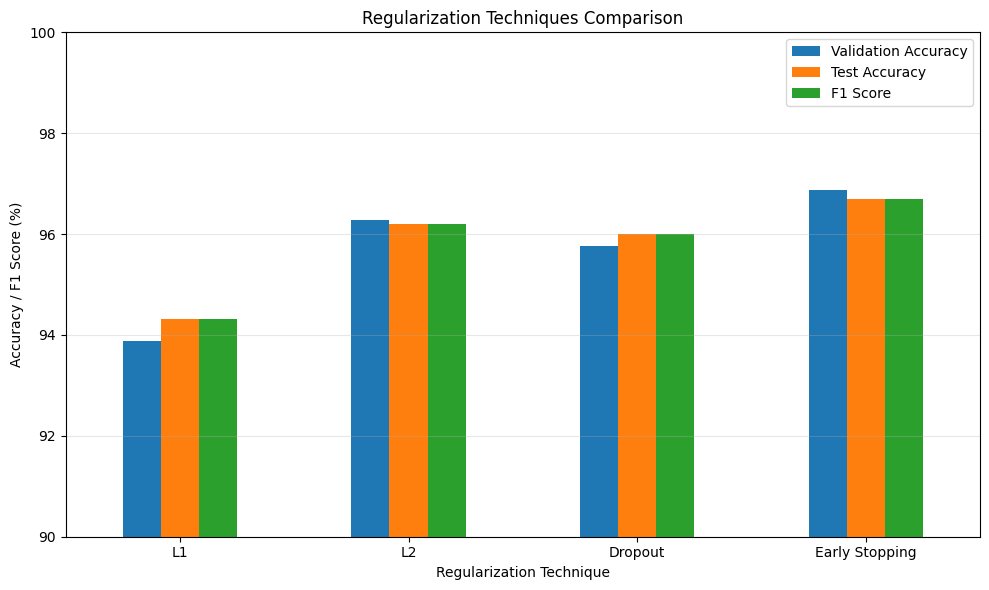

In [ ]:
plot_data = final_reg_results[
    ["Validation Accuracy", "Test Accuracy", "F1 Score"]
] * 100

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regularization Techniques Comparison")
plt.xlabel("Regularization Technique")
plt.ylabel("Accuracy / F1 Score (%)")
plt.ylim(90, 100)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

HYPER PARAMETER TUNING


In [ ]:
l2_values = [0.0001, 0.0005, 0.001]
learning_rates = [0.0005, 0.001, 0.002]
batch_sizes = [64, 128]

In [ ]:
tuning_results = []

for reg in l2_values:
    for lr in learning_rates:
        for batch in batch_sizes:

            model = Sequential([
                Flatten(input_shape=(28, 28)),

                Dense(64, activation='relu',
                      kernel_regularizer=l2(reg)),

                Dense(32, activation='relu',
                      kernel_regularizer=l2(reg)),

                Dense(16, activation='relu',
                      kernel_regularizer=l2(reg)),

                Dense(4, activation='relu',
                      kernel_regularizer=l2(reg)),

                Dense(10, activation='softmax')
            ])

            model.compile(
                optimizer=RMSprop(learning_rate=lr),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                X_train, y_train,
                epochs=10,
                batch_size=batch,
                validation_data=(X_val, y_val),
                verbose=0
            )

            best_val = max(history.history['val_accuracy'])

            tuning_results.append([
                reg, lr, batch, best_val
            ])

tuning_df = pd.DataFrame(
    tuning_results,
    columns=[
        "L2 Value",
        "Learning Rate",
        "Batch Size",
        "Best Validation Accuracy"
    ]
)

display(tuning_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,L2 Value,Learning Rate,Batch Size,Best Validation Accuracy
0,0.0001,0.0005,64,0.941333
1,0.0001,0.0005,128,0.859833
2,0.0001,0.0010,64,0.959000
3,0.0001,0.0010,128,0.957167
4,0.0001,0.0020,64,0.966500
5,0.0001,0.0020,128,0.963083
6,0.0005,0.0005,64,0.951667
7,0.0005,0.0005,128,0.841917
8,0.0005,0.0010,64,0.947167
9,0.0005,0.0010,128,0.952750


In [ ]:
best_params = tuning_df.loc[
    tuning_df["Best Validation Accuracy"].idxmax()
]

print("Best Hyperparameters")
print("--------------------")
print("L2 Value :", best_params["L2 Value"])
print("Learning Rate :", best_params["Learning Rate"])
print("Batch Size :", best_params["Batch Size"])
print(
    "Best Validation Accuracy :",
    best_params["Best Validation Accuracy"]
)

Best Hyperparameters
--------------------
L2 Value : 0.0001
Learning Rate : 0.002
Batch Size : 64.0
Best Validation Accuracy : 0.9664999842643738


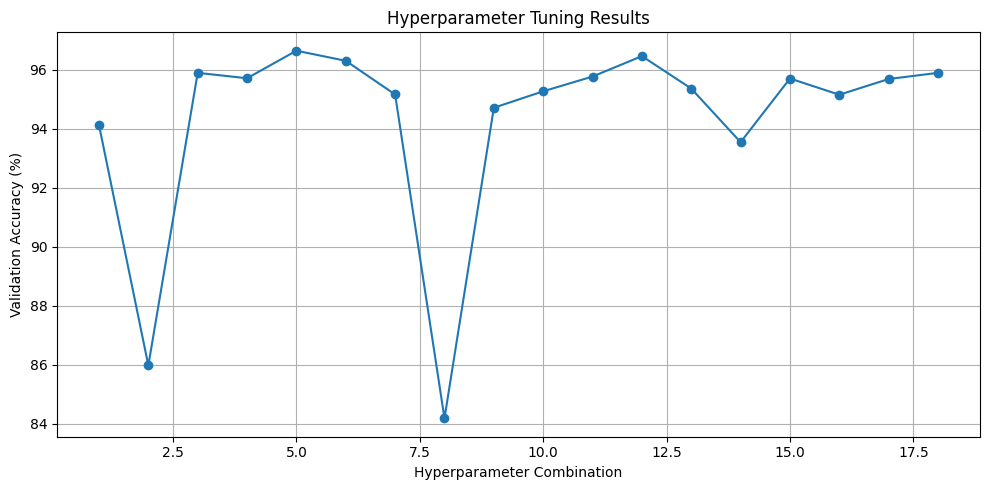

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tuning_df) + 1),
    tuning_df["Best Validation Accuracy"] * 100,
    marker='o'
)

plt.xlabel("Hyperparameter Combination")
plt.ylabel("Validation Accuracy (%)")
plt.title("Hyperparameter Tuning Results")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Final Tuned L2 Model

final_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(64, activation='relu',
          kernel_regularizer=l2(0.0001)),

    Dense(32, activation='relu',
          kernel_regularizer=l2(0.0001)),

    Dense(16, activation='relu',
          kernel_regularizer=l2(0.0001)),

    Dense(4, activation='relu',
          kernel_regularizer=l2(0.0001)),

    Dense(10, activation='softmax')
])

final_model.compile(
    optimizer=RMSprop(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_23 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,966 (206.90 KB)

 Trainable params: 52,966 (206.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

final_history = final_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

final_training_time = time.time() - start

print("Training Time:", final_training_time)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7078 - loss: 0.9166 - val_accuracy: 0.8932 - val_loss: 0.4789
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9201 - loss: 0.3480 - val_accuracy: 0.9388 - val_loss: 0.2873
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9445 - loss: 0.2500 - val_accuracy: 0.9482 - val_loss: 0.2460
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9554 - loss: 0.2065 - val_accuracy: 0.9557 - val_loss: 0.2114
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9622 - loss: 0.1770 - val_accuracy: 0.9590 - val_loss: 0.2080
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9678 - loss: 0.1583 - val_accuracy: 0.9660 - val_loss: 0.1799
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9710 - loss: 0.1448 - val_accuracy: 0.9653 - val_loss: 0.1750
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.1331 - val_accuracy: 0.

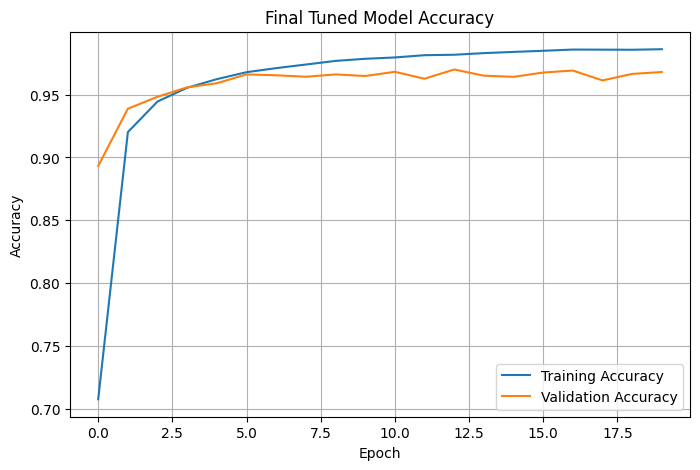

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    final_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Final Tuned Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
final_loss, final_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Predictions
final_pred = np.argmax(
    final_model.predict(X_test, verbose=0),
    axis=1
)

# Metrics
final_precision = precision_score(
    y_test,
    final_pred,
    average='weighted'
)

final_recall = recall_score(
    y_test,
    final_pred,
    average='weighted'
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average='weighted'
)

print("Final Tuned Model Results")
print("Final Test Loss     :", final_loss)
print("Final Test Accuracy :", final_accuracy)
print("Precision     :", final_precision)
print("Recall        :", final_recall)
print("F1 Score      :", final_f1)

Final Tuned Model Results
Final Test Loss     : 0.1917961984872818
Final Test Accuracy : 0.9681000113487244
Precision     : 0.9682516547041883
Recall        : 0.9681
F1 Score      : 0.9680962387535957


In [ ]:
print("Final Tuned Model - Classification Report")
print()

print(
    classification_report(
        y_test,
        final_pred
    )
)

Final Tuned Model - Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.95      0.98      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.95      0.97      0.96       892
           6       0.98      0.95      0.96       958
           7       0.96      0.98      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Figure size 700x700 with 0 Axes>

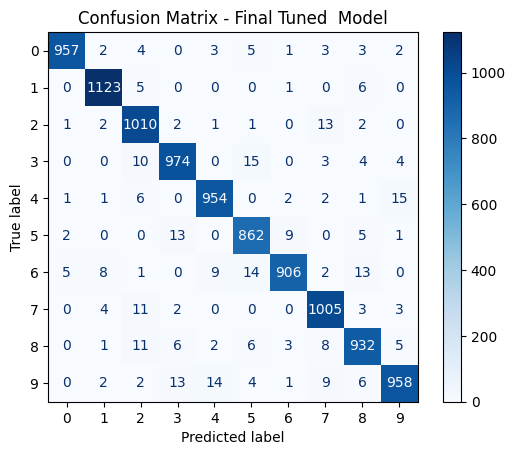

In [ ]:
cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - Final Tuned  Model")
plt.show()

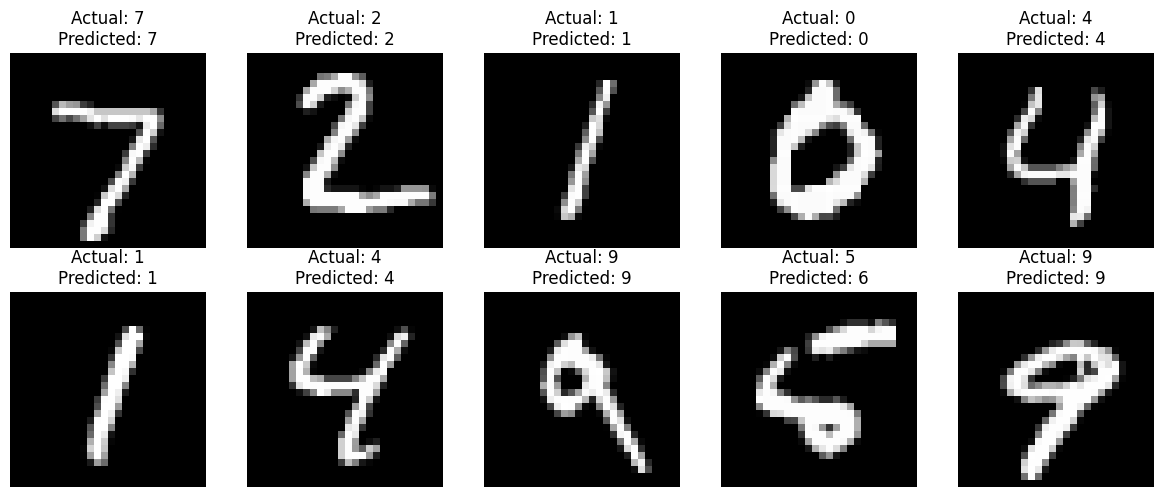

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {final_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
final_summary = pd.DataFrame({
    "Validation Accuracy": [
        results_df.loc[results_df["Method"] == "L1",
                       "Validation Accuracy"].iloc[0],

        results_df.loc[results_df["Method"] == "L2",
                       "Validation Accuracy"].iloc[0],

        results_df.loc[results_df["Method"] == "Dropout",
                       "Validation Accuracy"].iloc[0],

        early_val_accuracy,

        max(final_history.history["val_accuracy"])
    ],

    "Test Accuracy": [
        results_df.loc[results_df["Method"] == "L1",
                       "Test Accuracy"].iloc[0],

        results_df.loc[results_df["Method"] == "L2",
                       "Test Accuracy"].iloc[0],

        results_df.loc[results_df["Method"] == "Dropout",
                       "Test Accuracy"].iloc[0],

        early_accuracy,

        final_accuracy
    ],

    "F1 Score": [
        results_df.loc[results_df["Method"] == "L1",
                       "F1 Score"].iloc[0],

        results_df.loc[results_df["Method"] == "L2",
                       "F1 Score"].iloc[0],

        results_df.loc[results_df["Method"] == "Dropout",
                       "F1 Score"].iloc[0],

        early_f1,

        final_f1
    ]
},
index=[
    "L1",
    "L2",
    "Dropout",
    "Early Stopping",
    "Tuned "
])

display(final_summary)

,Validation Accuracy,Test Accuracy,F1 Score
L1,0.938833,0.9431,0.943184
L2,0.962750,0.9620,0.962015
Dropout,0.957667,0.9601,0.960054
Early Stopping,0.968750,0.9669,0.966871
Tuned,0.969917,0.9681,0.968096


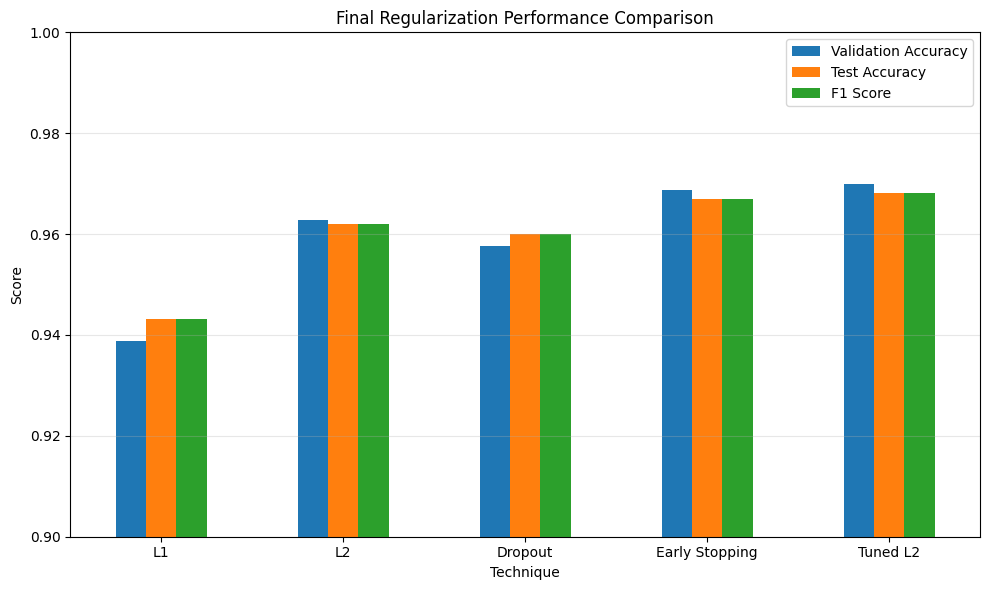

In [ ]:
final_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Regularization Performance Comparison")
plt.xlabel("Technique")
plt.ylabel("Score")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()